# Часть 1: Реализация метода k-ближайших соседей (kNN) и метрик расстояния


## Задание 1.1: Реализация метрик расстояния

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, precision_score, recall_score
import time
import heapq

# Метрики расстояния
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b), axis=1)

def cosine_distance (a, b):
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    similarity = 0
    if norm_a != 0 and norm_b != 0:
        similarity = dot / (norm_a * norm_b)
    return 1 - similarity

## Задание 1.2: Реализация алгоритма kNN (Brute-Force)

In [10]:
# Класс алгоритма
class MyKNN:
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test, k=3, metric='euclidean'):
        result = []
        for x in X_test:
            distances = []
            if metric == 'euclidean':
                distances = euclidean_distance(self.X_train, x)
            elif metric == 'manhattan':
                distances = manhattan_distance(self.X_train, x)
            elif metric == 'cosine':
                distances = cosine_distance(self.X_train, x)
            else:
                raise ValueError("Invalid value")
            knn_indexes = np.argsort(distances)[:k]
            targets = self.y_train[knn_indexes]
            tag = np.bincount(targets).argmax()
            result.append(tag)
        return np.array(result)

## Задание 1.3 Сравнение метрик и параметра к

In [11]:
#X1 - Обуч
X1, y1 = load_iris(return_X_y=True, as_frame=False)
#print(f"X1: {X1} |  y1: {y1}")
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2 ,random_state=0)
print(f"X1_train: {X1_train} | X1_test: {X1_test} | y1_train {y1_train} | y1_test {y1_test}")
knn_clf = MyKNN()
knn_clf.fit(X1_train, y1_train)
knn_clf_pred_res = knn_clf.predict(X1_test, 3)
print(f"Pred - {knn_clf_pred_res}")
print(f"Test - {y1_test}")
#Мерика качества
accuracy = accuracy_score(y1_test, knn_clf_pred_res)
print(f"Accuracy - {accuracy}")
precision = precision_score(y1_test, knn_clf_pred_res, average=None)
print(f"Precision(macro) - {precision}")
recall = recall_score(y1_test, knn_clf_pred_res, average=None)
print(f"Recall(macro) - {recall}")

X1_train: [[6.4 3.1 5.5 1.8]
 [5.4 3.  4.5 1.5]
 [5.2 3.5 1.5 0.2]
 [6.1 3.  4.9 1.8]
 [6.4 2.8 5.6 2.2]
 [5.2 2.7 3.9 1.4]
 [5.7 3.8 1.7 0.3]
 [6.  2.7 5.1 1.6]
 [5.9 3.  4.2 1.5]
 [5.8 2.6 4.  1.2]
 [6.8 3.  5.5 2.1]
 [4.7 3.2 1.3 0.2]
 [6.9 3.1 5.1 2.3]
 [5.  3.5 1.6 0.6]
 [5.4 3.7 1.5 0.2]
 [5.  2.  3.5 1. ]
 [6.5 3.  5.5 1.8]
 [6.7 3.3 5.7 2.5]
 [6.  2.2 5.  1.5]
 [6.7 2.5 5.8 1.8]
 [5.6 2.5 3.9 1.1]
 [7.7 3.  6.1 2.3]
 [6.3 3.3 4.7 1.6]
 [5.5 2.4 3.8 1.1]
 [6.3 2.7 4.9 1.8]
 [6.3 2.8 5.1 1.5]
 [4.9 2.5 4.5 1.7]
 [6.3 2.5 5.  1.9]
 [7.  3.2 4.7 1.4]
 [6.5 3.  5.2 2. ]
 [6.  3.4 4.5 1.6]
 [4.8 3.1 1.6 0.2]
 [5.8 2.7 5.1 1.9]
 [5.6 2.7 4.2 1.3]
 [5.6 2.9 3.6 1.3]
 [5.5 2.5 4.  1.3]
 [6.1 3.  4.6 1.4]
 [7.2 3.2 6.  1.8]
 [5.3 3.7 1.5 0.2]
 [4.3 3.  1.1 0.1]
 [6.4 2.7 5.3 1.9]
 [5.7 3.  4.2 1.2]
 [5.4 3.4 1.7 0.2]
 [5.7 4.4 1.5 0.4]
 [6.9 3.1 4.9 1.5]
 [4.6 3.1 1.5 0.2]
 [5.9 3.  5.1 1.8]
 [5.1 2.5 3.  1.1]
 [4.6 3.4 1.4 0.3]
 [6.2 2.2 4.5 1.5]
 [7.2 3.6 6.1 2.5]
 [5.7 2.9 4.2 1.3]
 [

# Часть 2: Реализация древовидных структур для ускорения kNN (BallTree / KD-Tree)

## Задание 2.1: Реализация BallTree

In [12]:
# класс дерева
class BallTree:
    # класс узла
    class Node:
        def __init__(self, centroid, radius, indices=None, left=None, right=None):
            self.centroid = centroid
            self.radius = radius
            self.indices = indices
            self.left = left
            self.right = right

        @property
        def is_leaf(self):
            return self.left is None and self.right is None

    def __init__(self, leaf_size=10):
        self.leaf_size = leaf_size
        self.root = None # корень дерева
        self.data = None # наши данные для обучения

    # выбор оси с наибольшей дисперсией
    def __pick_dimension(self, points):
        return int(np.argmax(points.max(axis=0) - points.min(axis=0)))

    # найти индекс центроида
    def __get_centroid_index(self, points, dimension):
        return int(np.argmin(np.abs(points[:, dimension] - points[:, dimension].mean())))

    # найти радиус гиперсферы
    def __get_radius(self, centroid, points):
        return float(np.max(np.linalg.norm(points - centroid, axis=1)))

    # построить дерево (публичный метод)
    def build_tree(self, data, leaf_size=None):
        if leaf_size is not None:
            self.leaf_size = leaf_size
        self.data = np.asarray(data, dtype=float)
        self.root = self.__build(np.arange(len(self.data))) # передаем диапазон индексов 1, 2, ..., n-1
        return self.root

    # рекурсивный метод построения дерева
    def __build(self, indices):
        points = self.data[indices] # выбираем множество точек
        dimension = self.__pick_dimension(points)
        order = np.argsort(points[:, dimension], kind='stable') # получаем порядок для сортировки
        indices, points = indices[order], points[order] # сортируем

        centroid_pos = self.__get_centroid_index(points, dimension)
        centroid = points[centroid_pos]
        radius = self.__get_radius(centroid, points)

        # условие выхода из рекурсии
        if len(indices) <= self.leaf_size:
            return self.Node(centroid, radius, indices=indices)

        # разделяем на части: до центроида и после, левая = часть [0, centroid_pos], правая = (centroid_pos, n-1]
        split = centroid_pos + 1
        # если centroid_pos указывает на последний элемент, тогда просто берем середину
        if split >= len(indices):
            split = len(indices) // 2

        left = self.__build(indices[:split])
        right = self.__build(indices[split:])
        return self.Node(centroid, radius, left=left, right=right)

    # обход дерева
    def query(self, point, k=1):
        """Возвращает (расстояния, индексы) k ближайших точек, по возрастанию расстояния."""
        point = np.asarray(point, dtype=float)
        heap = []  # элементы: (-расстояние, индекс); вершина = самый дальний из k
        self.__search(self.root, point, k, heap)

        result = sorted((-d, i) for d, i in heap) # сортируем по порядку 
        dists = np.array([d for d, _ in result]) # берем расстояния
        idxs = np.array([i for _, i in result]) # берем индексы
        return dists, idxs

    # обход дерева рекурсивный
    def __search(self, node, point, k, heap):
        # расстояние от текущей точки до центроида в другом узле
        d_centroid = np.linalg.norm(point - node.centroid)

        # отсечение: даже самая близкая возможная точка узла не лучше k-го кандидата
        if len(heap) == k and d_centroid - node.radius >= -heap[0][0]:
            return

        if node.is_leaf:
            # полный перебор внутри листа
            dists = np.linalg.norm(self.data[node.indices] - point, axis=1)
            for d, idx in zip(dists, node.indices):
                if len(heap) < k:
                    heapq.heappush(heap, (-d, int(idx)))
                elif d < -heap[0][0]:
                    heapq.heapreplace(heap, (-d, int(idx)))
            return

        # сначала идём в ближайший по центроиду дочерний узел
        d_left = np.linalg.norm(point - node.left.centroid)
        d_right = np.linalg.norm(point - node.right.centroid)
        first, second = (node.left, node.right) if d_left <= d_right else (node.right, node.left)

        self.__search(first, point, k, heap)
        self.__search(second, point, k, heap)

## Задание 2.2: Реализация KD-Tree

In [13]:
# класс дерева
class KDTree:
    # класс узла
    class Node:
        def __init__(self, axis=None, median=None, indices=None, left=None, right=None):
            self.axis = axis        # ось, по которой делили
            self.median = median    # значение медианы по этой оси (гиперплоскость)
            self.indices = indices  # индексы точек (только у листа)
            self.left = left
            self.right = right

        @property
        def is_leaf(self):
            return self.left is None and self.right is None

    def __init__(self, leaf_size=10):
        self.leaf_size = leaf_size
        self.root = None
        self.data = None
        
    # выбор оси с наибольшей дисперсией
    def __pick_dimension(self, points):
        return int(np.argmax(points.var(axis=0)))

    # построить дерево (публичный метод)
    def build_tree(self, data, leaf_size=None):
        if leaf_size is not None:
            self.leaf_size = leaf_size
        self.data = np.asarray(data, dtype=float)
        self.root = self.__build(np.arange(len(self.data)))
        return self.root

    # рекурсивный метод построения дерева
    def __build(self, indices):
        # лист: точек мало
        if len(indices) <= self.leaf_size:
            return self.Node(indices=indices)

        points = self.data[indices]
        axis = self.__pick_dimension(points)

        # сортируем по оси и делим по медиане
        order = np.argsort(points[:, axis], kind='stable')
        indices = indices[order]
        mid = len(indices) // 2
        median = self.data[indices[mid], axis]

        # слева значения <= median, справа >= median
        left = self.__build(indices[:mid])
        right = self.__build(indices[mid:])
        return self.Node(axis=axis, median=median, left=left, right=right)

    # обход дерева
    def query(self, point, k=1):
        """Возвращает (расстояния, индексы) k ближайших точек по возрастанию расстояния."""
        point = np.asarray(point, dtype=float)
        heap = []  # (-расстояние, индекс)
        self.__search(self.root, point, k, heap)

        result = sorted((-d, i) for d, i in heap)
        dists = np.array([d for d, _ in result])
        idxs = np.array([i for _, i in result])
        return dists, idxs

    # обход дерева рекурсивный
    def __search(self, node, point, k, heap):
        if node.is_leaf:
            dists = np.linalg.norm(self.data[node.indices] - point, axis=1)
            for d, idx in zip(dists, node.indices):
                if len(heap) < k:
                    heapq.heappush(heap, (-d, int(idx)))
                elif d < -heap[0][0]:
                    heapq.heapreplace(heap, (-d, int(idx)))
            return

        # с какой стороны гиперплоскости лежит запрос
        diff = point[node.axis] - node.median
        near, far = (node.left, node.right) if diff < 0 else (node.right, node.left)

        # сначала ближняя сторона
        self.__search(near, point, k, heap)

        # дальнюю смотрим, только если плоскость ближе, чем k-й кандидат
        if len(heap) < k or abs(diff) < -heap[0][0]:
            self.__search(far, point, k, heap)

## Задание 2.3: Интеграция с KNN

In [18]:
# Класс алгоритма
class MyKNN:
    def fit(self, X_train, y_train, algorithm=None, leaf_size=10):
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        self.tree = None
        # деревья строятся один раз, при обучении
        if algorithm == 'ball_tree':
            self.tree = BallTree(leaf_size)
            self.tree.build_tree(self.X_train)
        elif algorithm == 'kd_tree':
            self.tree = KDTree(leaf_size)
            self.tree.build_tree(self.X_train)
        elif algorithm is not None:
            raise ValueError("Invalid value")
        self.fitted_algorithm = algorithm

    def predict(self, X_test, k=3, metric='euclidean', algorithm=None):
        if algorithm is None:
            result = []
            for x in X_test:
                if metric == 'euclidean':
                    distances = euclidean_distance(self.X_train, x)
                elif metric == 'manhattan':
                    distances = manhattan_distance(self.X_train, x)
                elif metric == 'cosine':
                    distances = cosine_distance(self.X_train, x)
                else:
                    raise ValueError("Invalid value")
                knn_indexes = np.argsort(distances)[:k]
                targets = self.y_train[knn_indexes]
                result.append(np.bincount(targets).argmax())
            return np.array(result)

        elif algorithm in ('ball_tree', 'kd_tree'):
            if metric != 'euclidean':
                raise ValueError("Деревья реализованы только для евклидовой метрики")
            # если дерево нужного типа не построено в fit, строим здесь
            if self.tree is None or self.fitted_algorithm != algorithm:
                cls = BallTree if algorithm == 'ball_tree' else KDTree
                self.tree = cls(10)
                self.tree.build_tree(self.X_train)
                self.fitted_algorithm = algorithm
            return self.__predict_tree(X_test, k)

        else:
            raise ValueError("Invalid value")

    def __predict_tree(self, X_test, k):
        result = []
        for x in X_test:
            _, idxs = self.tree.query(x, k)
            result.append(np.bincount(self.y_train[idxs]).argmax())
        return np.array(result)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 2 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 2 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 2 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


# Часть 3: Метрики бинарной классификации

## Задание 3.1: Бинаризация задачи

In [12]:
POSITIVE_CLASS = 0
def binarize(y, positive_class=POSITIVE_CLASS):
    # 1 - если объект принадлежит выбранному классу, иначе 0
    return (y == positive_class).astype(int)

# бинаризуем уже существующие метки из 1.3
y1_bin = binarize(y1)
y1_train_bin = binarize(y1_train)
y1_test_bin = binarize(y1_test)

print("y1:", y1)
print("y1_train:", y1_train)
print("y1_train:", y1_test_bin)

names = load_iris().target_names
print(f"Положительный класс (1): {names[POSITIVE_CLASS]}")
print(f"Отрицательный класс (0): {', '.join(n for i, n in enumerate(names) if i != POSITIVE_CLASS)}")

print("\nВся выборка:  ", dict(zip(*np.unique(y1_bin, return_counts=True))))
print("Обучающая:    ", dict(zip(*np.unique(y1_train_bin, return_counts=True))))
print("Тестовая:     ", dict(zip(*np.unique(y1_test_bin, return_counts=True))))

print("\nБыло (3 класса):", y1_test[:10])
print("Стало (2 класса):", y1_test_bin[:10])

y1: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
y1_train: [2 1 0 2 2 1 0 1 1 1 2 0 2 0 0 1 2 2 2 2 1 2 1 1 2 2 2 2 1 2 1 0 2 1 1 1 1
 2 0 0 2 1 0 0 1 0 2 1 0 1 2 1 0 2 2 2 2 0 0 2 2 0 2 0 2 2 0 0 2 0 0 0 1 2
 2 0 0 0 1 1 0 0 1 0 2 1 2 1 0 2 0 2 0 0 2 0 2 1 1 1 2 2 1 1 0 1 2 2 0 1 1
 1 1 0 0 0 2 1 2 0]
y1_train: [0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 0 0 1]
Положительный класс (1): setosa
Отрицательный класс (0): versicolor, virginica

Вся выборка:   {np.int64(0): np.int64(100), np.int64(1): np.int64(50)}
Обучающая:     {np.int64(0): np.int64(81), np.int64(1): np.int64(39)}
Тестовая:      {np.int64(0): np.int64(19), np.int64(1): np.int64(11)}

Было (3 класса): [2 1 0 2 0 2 0 1 1 1]
Стало (2 класса): [0 0 1 0 1 0 1

## Задание 3.2: Расчет метрик классификации "с нуля"

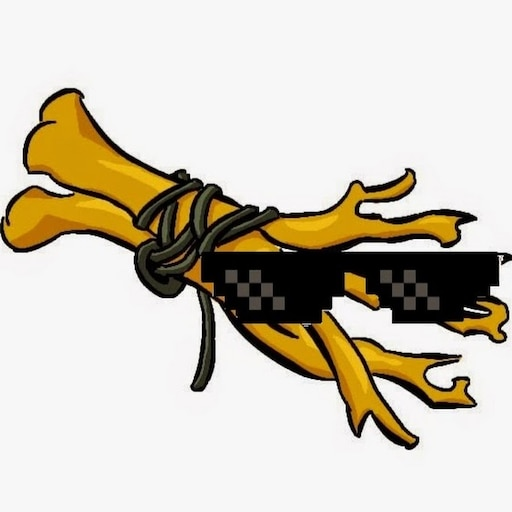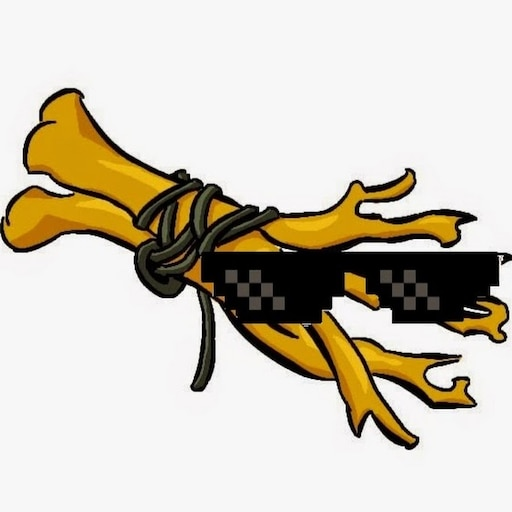